In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os


SAVE_DIR = "../evaluation/plots/ckd"
os.makedirs(SAVE_DIR, exist_ok=True)

df=pd.read_csv('../data/processed/ckd/ckd_processed.csv')
df.head()

,sc,al,age,prognosis,egfr
0,1.2,1.0,48.0,1,53.569775
1,0.8,4.0,7.0,1,116.652746
2,1.8,2.0,62.0,1,29.738220
3,3.8,4.0,48.0,1,13.295099
4,1.4,2.0,51.0,1,43.534033


In [9]:
#dataset inf
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sc         400 non-null    float64
 1   al         400 non-null    float64
 2   age        400 non-null    float64
 3   prognosis  400 non-null    int64  
 4   egfr       400 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 15.8 KB


,sc,al,age,prognosis,egfr
count,400.000000,400.00000,400.000000,400.000000,400.000000
mean,2.997125,0.90000,51.562500,0.625000,53.947178
std,5.628886,1.31313,16.982996,0.484729,43.671089
min,0.400000,0.00000,2.000000,0.000000,0.326691
25%,0.900000,0.00000,42.000000,0.000000,19.168343
50%,1.300000,0.00000,55.000000,1.000000,46.298875
75%,2.725000,2.00000,64.000000,1.000000,75.799324
max,76.000000,5.00000,90.000000,1.000000,226.241069


In [10]:
df.isnull().sum()

sc           0
al           0
age          0
prognosis    0
egfr         0
dtype: int64

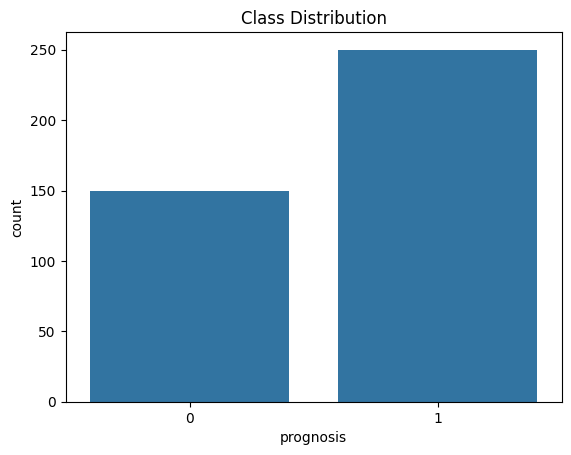

In [11]:
#class distribution
sns.countplot(x='prognosis',data=df)
plt.title('Class Distribution')
plt.savefig(f'{SAVE_DIR}/class_distribution_ckd.png',dpi=300,bbox_inches='tight')
plt.show()

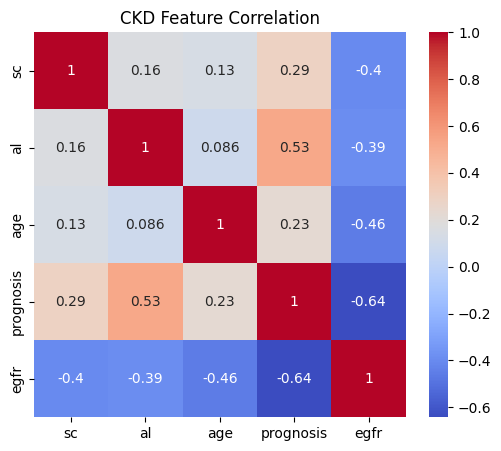

In [12]:
#correlation
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("CKD Feature Correlation")

plt.savefig(f'{SAVE_DIR}/correlation_heatmap.png',dpi=300,bbox_inches='tight')
plt.show()

### Correlation Analysis (CKD)

- eGFR shows a strong negative correlation with CKD prognosis (r = −0.64), confirming its role as a primary indicator of kidney function decline.
- Albumin demonstrates a moderate positive correlation (r = 0.53), supporting its importance as a marker of kidney damage.
- Serum creatinine shows a weaker correlation (r = 0.29), highlighting the limitation of using creatinine alone and justifying eGFR feature engineering.
- Age exhibits a weak positive correlation (r = 0.23), indicating that CKD risk increases with age but cannot be determined solely based on age.


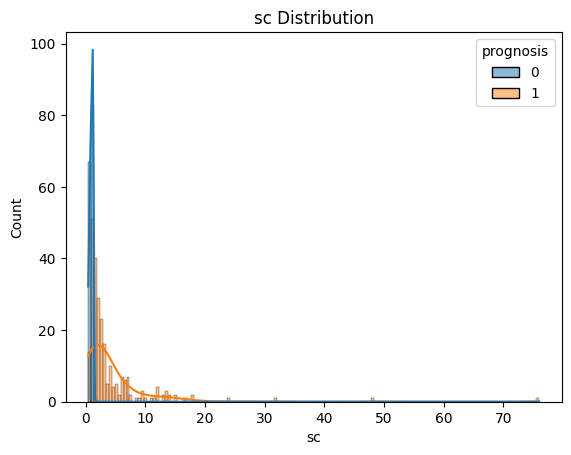

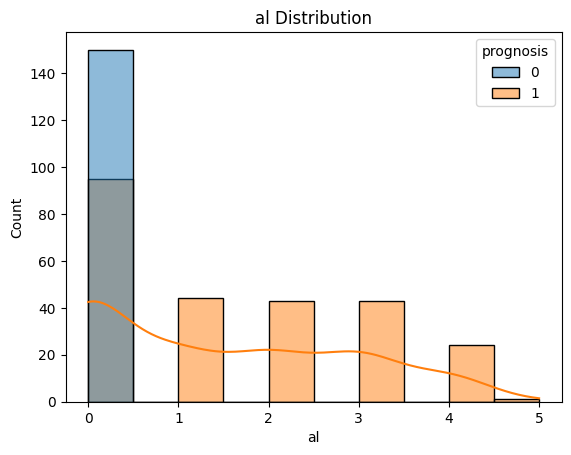

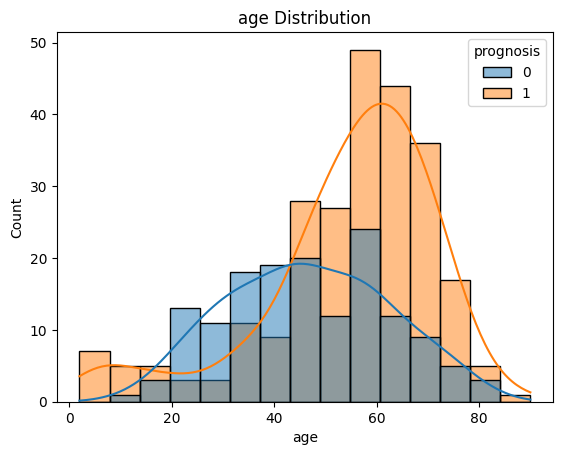

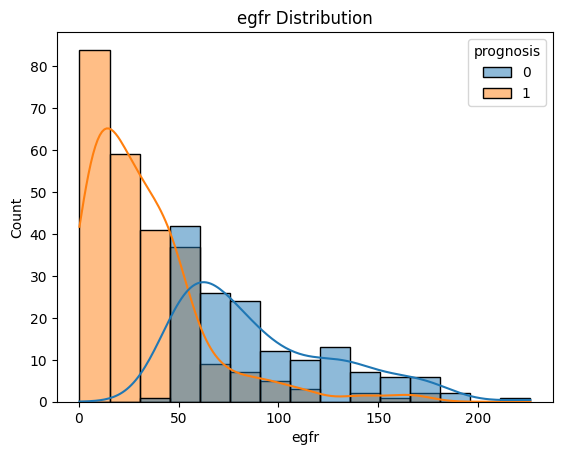

In [13]:
for col in df.columns:
    if col !="prognosis":
        plt.figure()
        sns.histplot(data=df,x=col,hue='prognosis',kde=True)
        plt.title(f'{col} Distribution')

        plt.savefig(f'{SAVE_DIR}/{col}_distribution.png',dpi=300,bbox_inches='tight')
        plt.show()

### Feature Distribution – Serum Creatinine

- Serum creatinine levels are generally higher in CKD patients compared to non-CKD individuals.
- The CKD class shows a wider distribution with a pronounced right tail, reflecting varying disease severity.
- Noticeable overlap exists between the two classes at lower creatinine values, indicating that serum creatinine alone may not reliably distinguish early-stage CKD.
- This observation further supports the use of derived measures such as eGFR for improved discrimination.


### Feature Distribution – Albumin

- Albumin values are concentrated near zero for non-CKD individuals, indicating absence of protein leakage.
- CKD patients show a wider distribution of albumin levels ranging from 1 to 5, reflecting varying degrees of kidney damage.
- Minimal overlap is observed between CKD and non-CKD classes, suggesting that albumin is a strong discriminator for kidney disease.


### Feature Distribution – Age

- CKD patients tend to be older on average, with the distribution shifted toward higher age values.
- Significant overlap exists between CKD and non-CKD groups across most age ranges.
- This indicates that while age contributes to CKD risk, it cannot reliably distinguish CKD status on its own and serves as a supporting rather than primary feature.


### Feature Distribution – eGFR

- eGFR values show clear separation between CKD and non-CKD groups, with CKD patients concentrated at lower eGFR levels.
- Non-CKD individuals predominantly exhibit higher eGFR values, reflecting normal kidney function.
- Limited overlap is observed in the mid-range, corresponding to early-stage or borderline CKD cases.
- Overall, eGFR demonstrates strong discriminative ability and serves as a primary indicator of CKD.




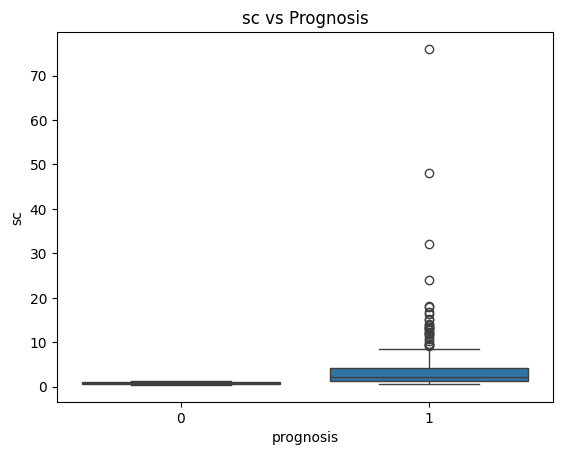

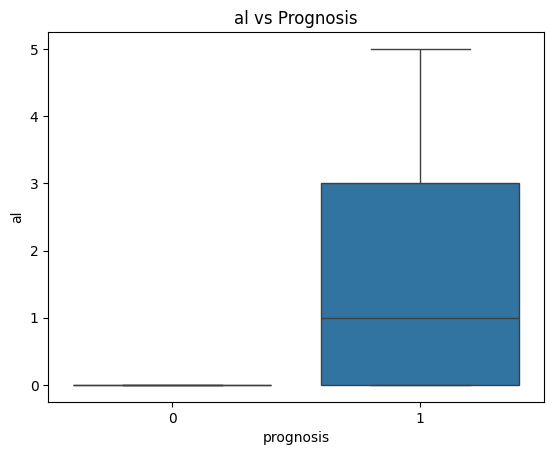

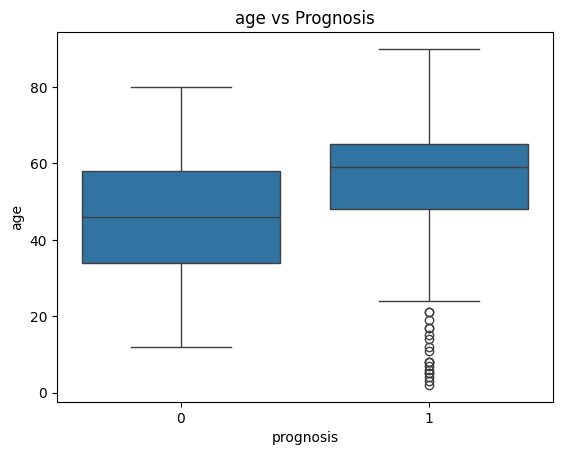

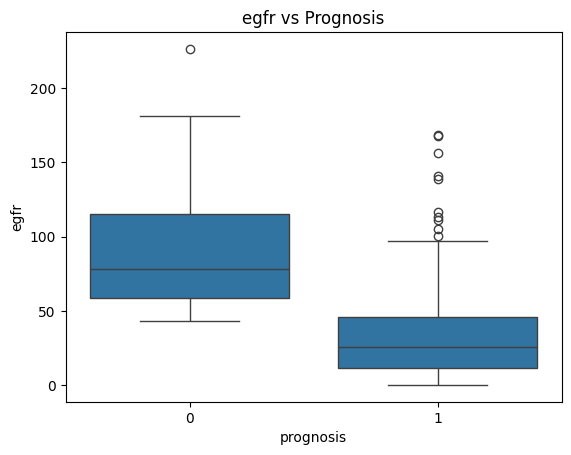

In [14]:
for col in df.columns:
    if col != "prognosis":
        plt.figure()
        sns.boxplot(x="prognosis", y=col, data=df)
        plt.title(f"{col} vs Prognosis")

        plt.savefig(f"{SAVE_DIR}/{col}_boxplot.png",
                    dpi=300,
                    bbox_inches="tight")
        plt.show()


### Boxplot Analysis – Serum Creatinine vs Prognosis

- CKD patients exhibit a significantly higher median serum creatinine level compared to non-CKD individuals.
- The CKD class shows a wide interquartile range and numerous extreme outliers, reflecting varying disease severity.
- Overlap between the two classes at lower creatinine values suggests limited discriminative ability of serum creatinine alone in early-stage CKD.

### Boxplot Analysis – Albumin vs Prognosis

- Non-CKD individuals exhibit albumin values concentrated at zero, indicating absence of protein leakage.
- CKD patients show a higher median albumin level with a wide interquartile range, reflecting varying severity of kidney damage.
- Minimal overlap between the two groups suggests that albumin is a strong indicator of CKD.


### Boxplot Analysis – Age vs Prognosis

- CKD patients exhibit a higher median age compared to non-CKD individuals.
- Substantial overlap exists between the two groups, indicating that age alone cannot reliably distinguish CKD status.
- The presence of younger CKD outliers suggests that CKD can occur across a wide age range.


### Boxplot Analysis – eGFR vs Prognosis

- CKD patients exhibit substantially lower median eGFR values compared to non-CKD individuals.
- The interquartile ranges of the two groups show minimal overlap, indicating strong discriminative ability.
- These findings confirm eGFR as a primary indicator of kidney function decline and CKD status.
'
